In [1]:
!pip install transformers tqdm seaborn scikit-learn nltk

# Imports
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax
import torch

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

plt.style.use('ggplot')
tqdm.pandas()

# Download NLTK resources
nltk.download('vader_lexicon')
nltk.download('punkt')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [2]:
# Upload your Reviews.csv file in Colab
from google.colab import files
uploaded = files.upload()

# Load dataset
df = pd.read_csv('Reviews.csv')

# Use subset for speed (increase later)
df = df.head(2000)

df['Text'] = df['Text'].astype(str)
print(df.shape)
df.head()

Saving Reviews.csv to Reviews.csv
(2000, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [4]:
def clean_text(text):
  text = text.lower()
  text = re.sub(r"http\S+", "", text)
  text = re.sub(r"<.*?>", "", text)
  text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
  text = re.sub(r"\s+", " ", text).strip()
  return text
df['clean_text'] = df['Text'].progress_apply(clean_text)

df['text_length'] = df['clean_text'].apply(len)
df['num_exclaim'] = df['Text'].str.count('!')
df['num_question'] = df['Text'].str.count('\?')
df.head()

<>:12: SyntaxWarning: invalid escape sequence '\?'
<>:12: SyntaxWarning: invalid escape sequence '\?'
/tmp/ipykernel_2103/3246882513.py:12: SyntaxWarning: invalid escape sequence '\?'
  df['num_question'] = df['Text'].str.count('\?')


  0%|          | 0/2000 [00:00<?, ?it/s]

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,clean_text,text_length,num_exclaim,num_question
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,i have bought several of the vitality canned d...,259,0,0
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled as jumbo salted peanut...,183,0,0
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,this is a confection that has been around a fe...,484,0,0
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,if you are looking for the secret ingredient i...,212,0,0
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,great taffy at a great price there was a wide ...,132,0,0


In [5]:
aspects = ['taste','delivery','quality','price','packaging','battery']

for aspect in aspects:
    df[f'aspect_{aspect}'] = df['clean_text'].apply(lambda x: int(aspect in x))

df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,clean_text,text_length,num_exclaim,num_question,aspect_taste,aspect_delivery,aspect_quality,aspect_price,aspect_packaging,aspect_battery
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,i have bought several of the vitality canned d...,259,0,0,0,0,1,0,0,0
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled as jumbo salted peanut...,183,0,0,0,0,0,0,0,0
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,this is a confection that has been around a fe...,484,0,0,0,0,0,0,0,0
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,if you are looking for the secret ingredient i...,212,0,0,0,0,0,0,0,0
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,great taffy at a great price there was a wide ...,132,0,0,0,1,0,1,0,0


In [6]:
sia = SentimentIntensityAnalyzer()

df[['vader_neg','vader_neu','vader_pos','vader_compound']] = df['clean_text'].progress_apply(
    lambda x: pd.Series(sia.polarity_scores(x))
)
df.head()

  0%|          | 0/2000 [00:00<?, ?it/s]

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,...,aspect_taste,aspect_delivery,aspect_quality,aspect_price,aspect_packaging,aspect_battery,vader_neg,vader_neu,vader_pos,vader_compound
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,...,0,0,1,0,0,0,0.000,0.695,0.305,0.9441
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,...,0,0,0,0,0,0,0.138,0.862,0.000,-0.5664
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,...,0,0,0,0,0,0,0.091,0.754,0.155,0.8265
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,...,0,0,0,0,0,0,0.000,0.925,0.075,0.4404
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,...,0,1,0,1,0,0,0.000,0.552,0.448,0.9468


In [7]:
MODEL = "cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

def batch_roberta(texts, batch_size=32):
    all_scores = []

    for i in tqdm(range(0, len(texts), batch_size)):
      batch = texts[i:i+batch_size]

      encoded = tokenizer(batch.tolist(), return_tensors='pt', padding=True, truncation=True, max_length=128)
      encoded = {k: v.to(device) for k,v in encoded.items()}

      with torch.no_grad():
        outputs = model(**encoded)
        logits = outputs.logits.cpu().numpy()
        probs = softmax(logits, axis=1)

      all_scores.extend(probs)

    return pd.DataFrame(all_scores, columns=['roberta_neg','roberta_neu','roberta_pos'])

roberta_df = batch_roberta(df['clean_text'], batch_size=64)
df = pd.concat([df.reset_index(drop=True), roberta_df], axis=1)
df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/32 [00:00<?, ?it/s]

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,...,aspect_price,aspect_packaging,aspect_battery,vader_neg,vader_neu,vader_pos,vader_compound,roberta_neg,roberta_neu,roberta_pos
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,...,0,0,0,0.000,0.695,0.305,0.9441,0.007418,0.035487,0.957095
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,...,0,0,0,0.138,0.862,0.000,-0.5664,0.405942,0.559726,0.034332
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,...,0,0,0,0.091,0.754,0.155,0.8265,0.001910,0.067943,0.930147
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,...,0,0,0,0.000,0.925,0.075,0.4404,0.001630,0.055117,0.943254
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,...,1,0,0,0.000,0.552,0.448,0.9468,0.001615,0.009385,0.989000


In [8]:
df.to_csv("processed_reviews.csv", index=False)

In [9]:
from google.colab import files
files.download("processed_reviews.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

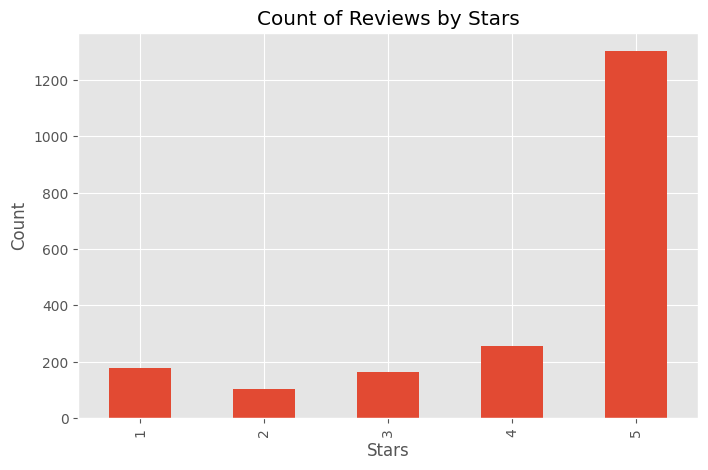

In [29]:
#EDA
# 1. Count of Reviews by Stars
plt.figure(figsize=(8,5))
df['Score'].value_counts().sort_index().plot(kind='bar')
plt.title('Count of Reviews by Stars')
plt.xlabel('Stars')
plt.ylabel('Count')
plt.show()


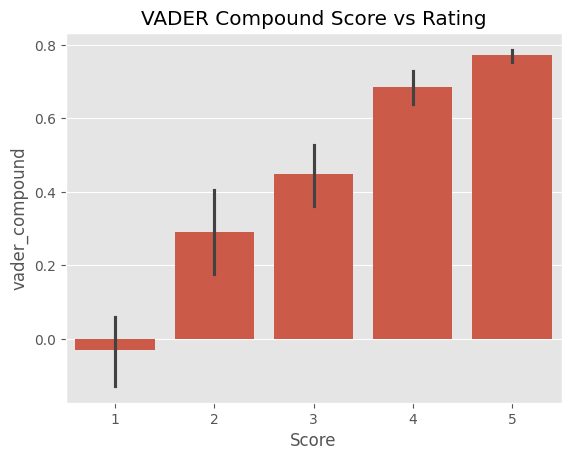

In [30]:
# 2. VADER Compound vs Score
sns.barplot(data=df, x='Score', y='vader_compound')
plt.title('VADER Compound Score vs Rating')
plt.show()

SyntaxError: invalid character '…' (U+2026) (883152750.py, line 3)

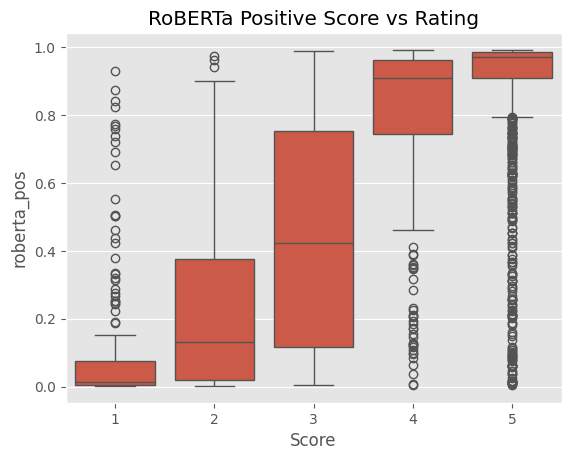

In [32]:
# 4. RoBERTa Positive vs Score
sns.boxplot(data=df, x='Score', y='roberta_pos')
plt.title('RoBERTa Positive Score vs Rating')
plt.show()

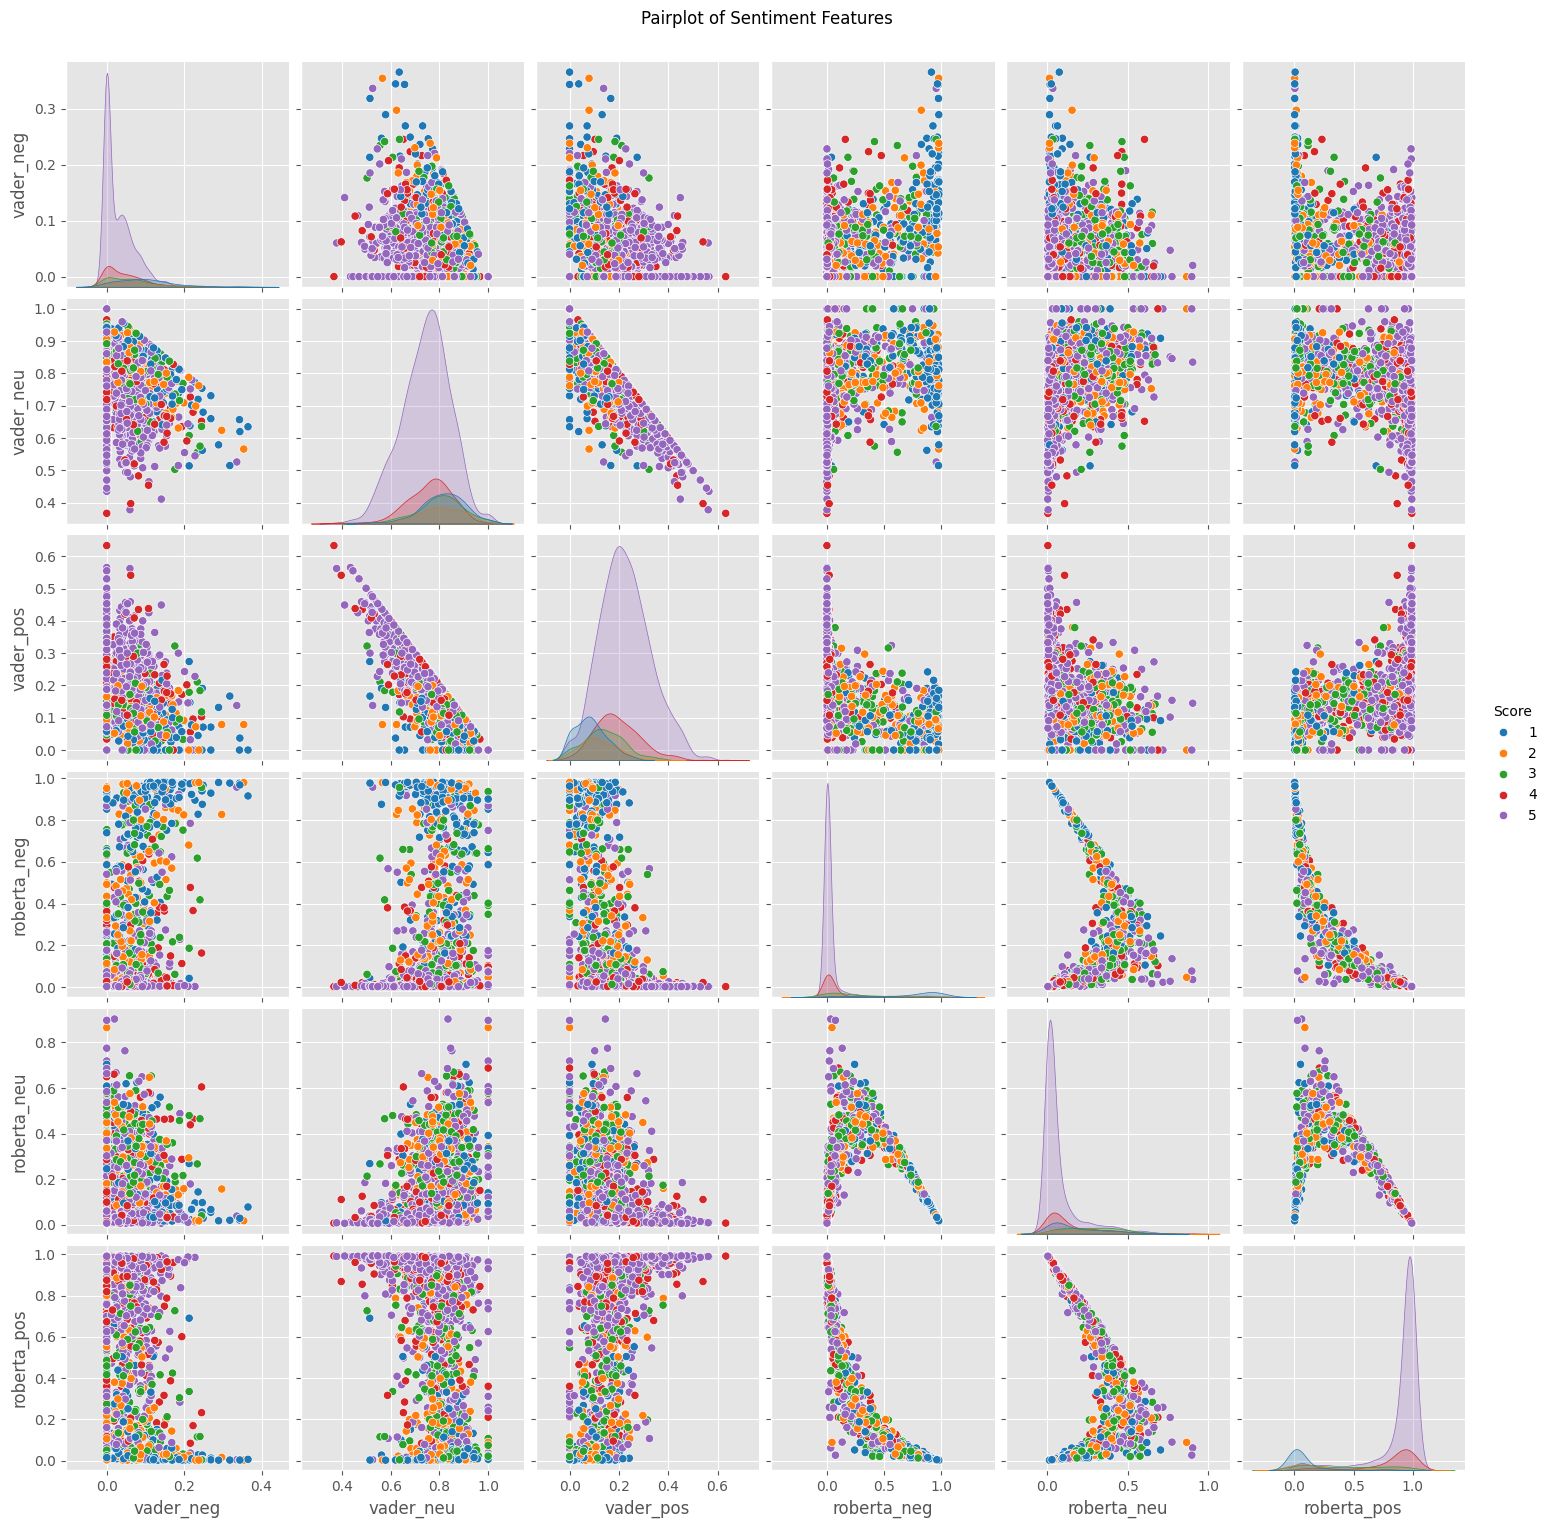

In [33]:
#PAIRPLOT
import seaborn as sns
import matplotlib.pyplot as plt

pairplot_cols = [
    'vader_neg', 'vader_neu', 'vader_pos',
    'roberta_neg', 'roberta_neu', 'roberta_pos'
]
sns.pairplot(
  data=df,
  vars=pairplot_cols,
  hue='Score',
  palette='tab10'
)
plt.suptitle("Pairplot of Sentiment Features", y=1.02)
plt.show()

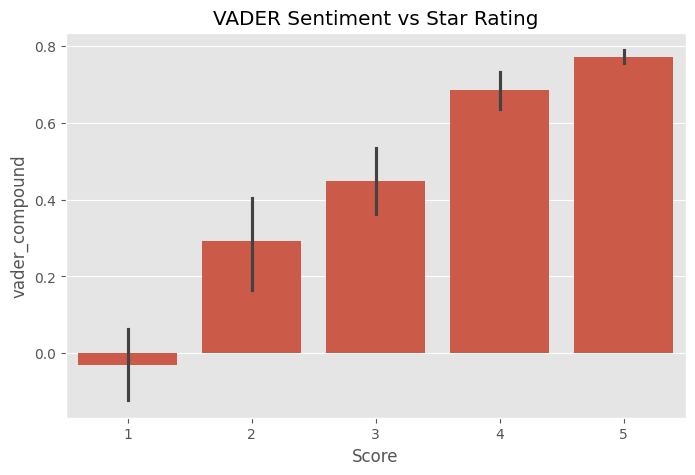

In [10]:
# VADER vs Score
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Score', y='vader_compound')
plt.title('VADER Sentiment vs Star Rating')
plt.show()

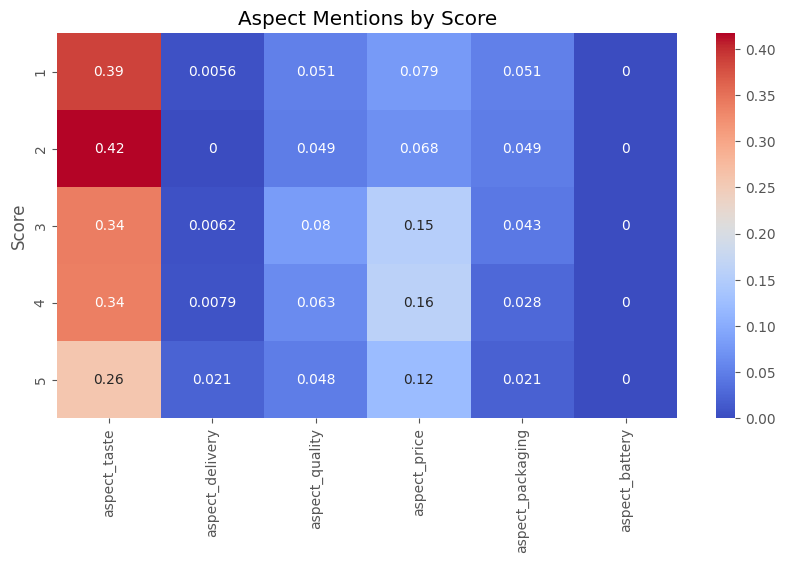

In [11]:
aspect_cols = [f'aspect_{a}' for a in aspects]
plt.figure(figsize=(10,5))
sns.heatmap(df.groupby('Score')[aspect_cols].mean(), annot=True, cmap='coolwarm')
plt.title('Aspect Mentions by Score')
plt.show()

In [12]:
feature_cols = ['vader_neg','vader_neu','vader_pos','vader_compound',
                'roberta_neg','roberta_neu','roberta_pos',
                'text_length','num_exclaim','num_question'] + aspect_cols
X = df[feature_cols]
y = df['Score']
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42
)

In [13]:
clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.59      0.72      0.65        40
           2       0.83      0.23      0.36        22
           3       0.23      0.19      0.20        27
           4       0.00      0.00      0.00        49
           5       0.78      0.95      0.86       262

    accuracy                           0.72       400
   macro avg       0.49      0.42      0.41       400
weighted avg       0.63      0.72      0.66       400



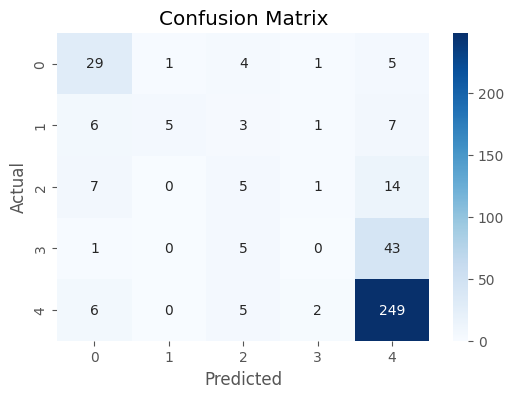

In [14]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

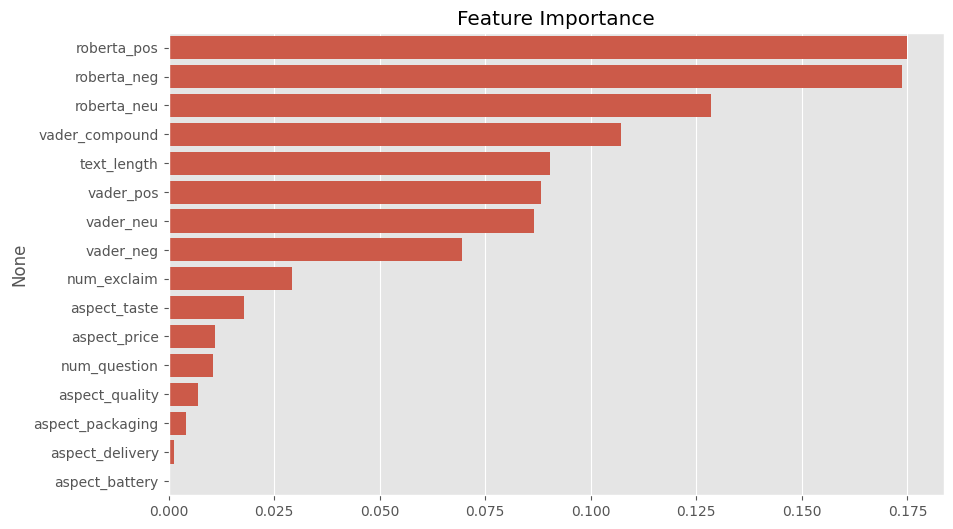

In [15]:
importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importances.values, y=importances.index)
plt.title('Feature Importance')
plt.show()

In [16]:
# Pick a random review
sample = df.sample(1)

print("Review:", sample['Text'].values[0])
print("Actual Score:", sample['Score'].values[0])

pred = clf.predict(sample[feature_cols])[0]
print("Predicted Score:", pred)

Review: This has been the best tasting Stevia I have tried.  I also think this is a better value than some of the others.  I really like not having to open all the packets when I make a gallon of Tea.
Actual Score: 5
Predicted Score: 5


In [22]:
def predict_review(text):
  cleaned = clean_text(text)

  # Basic features
  text_length = len(cleaned)
  num_exclaim = text.count('!')
  num_question = text.count('?')

  # Aspect features
  aspect_features = [int(aspect in cleaned) for aspect in aspects]

  # VADER
  vader = sia.polarity_scores(cleaned)

  # RoBERTa (single input)
  encoded = tokenizer(text, return_tensors='pt', truncation=True).to(device)
  with torch.no_grad():
    output = model(**encoded)
    scores = softmax(output.logits.cpu().numpy()[0])

  roberta = {
      'roberta_neg': scores[0],
      'roberta_neu': scores[1],
      'roberta_pos': scores[2]
  }
  # Combine all features
  features = [
    vader['neg'], vader['neu'], vader['pos'], vader['compound'],
    roberta['roberta_neg'], roberta['roberta_neu'], roberta['roberta_pos'],
    text_length, num_exclaim, num_question
  ] + aspect_features



  input_df = pd.DataFrame([features], columns=feature_cols)
  prediction = clf.predict(input_df)[0]

  print("🔹 Review:", text)
  print("🔹 Predicted Rating:", prediction)
  print("🔹 VADER Sentiment:", vader)
  print("🔹 RoBERTa Sentiment:", roberta)

In [27]:
predict_review("I love sentiment analysis.")

🔹 Review: I love sentiment analysis.
🔹 Predicted Rating: 5
🔹 VADER Sentiment: {'neg': 0.0, 'neu': 0.323, 'pos': 0.677, 'compound': 0.6369}
🔹 RoBERTa Sentiment: {'roberta_neg': np.float32(0.006067611), 'roberta_neu': np.float32(0.042539645), 'roberta_pos': np.float32(0.95139277)}
